# Experiment 3B: Random-Label Memorization with Longer SGD Training

## Research Question

Can a highly overparameterized neural network memorize randomly assigned training labels when trained for a longer duration using SGD?

## Objective

The objective of this experiment is to determine whether increasing the training duration enables the overparameterized network to memorize randomly assigned labels.

This experiment extends Experiment 3A by using the same random-label setting and SGD optimizer, but increasing the training duration from 30 to 100 epochs.

### Experimental Configuration

- Dataset: MNIST
- Width: 2048
- Parameters: 10,020,874
- Optimizer: SGD
- Learning rate: 0.01
- Batch size: 128
- Epochs: 100
- Labels: Randomly assigned

Device: cuda
Width: 2048
Epochs: 100
Batch size: 128
Learning rate: 0.01


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 462kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.21MB/s]



Parameters: 10020874
Epoch 001/100 | Train Loss: 2.3027 | Train Acc: 9.93% | Test Loss: 2.3012 | Test Acc: 8.88%
Epoch 002/100 | Train Loss: 2.3025 | Train Acc: 10.16% | Test Loss: 2.3012 | Test Acc: 6.90%
Epoch 003/100 | Train Loss: 2.3023 | Train Acc: 10.41% | Test Loss: 2.3014 | Test Acc: 6.91%
Epoch 004/100 | Train Loss: 2.3022 | Train Acc: 10.40% | Test Loss: 2.3013 | Test Acc: 6.61%
Epoch 005/100 | Train Loss: 2.3021 | Train Acc: 10.54% | Test Loss: 2.3015 | Test Acc: 7.91%
Epoch 006/100 | Train Loss: 2.3020 | Train Acc: 10.66% | Test Loss: 2.3015 | Test Acc: 7.16%
Epoch 007/100 | Train Loss: 2.3018 | Train Acc: 10.61% | Test Loss: 2.3015 | Test Acc: 8.91%
Epoch 008/100 | Train Loss: 2.3017 | Train Acc: 11.05% | Test Loss: 2.3017 | Test Acc: 9.48%
Epoch 009/100 | Train Loss: 2.3016 | Train Acc: 10.80% | Test Loss: 2.3017 | Test Acc: 9.30%
Epoch 010/100 | Train Loss: 2.3015 | Train Acc: 10.83% | Test Loss: 2.3018 | Test Acc: 9.41%
Epoch 011/100 | Train Loss: 2.3014 | Train Acc: 1

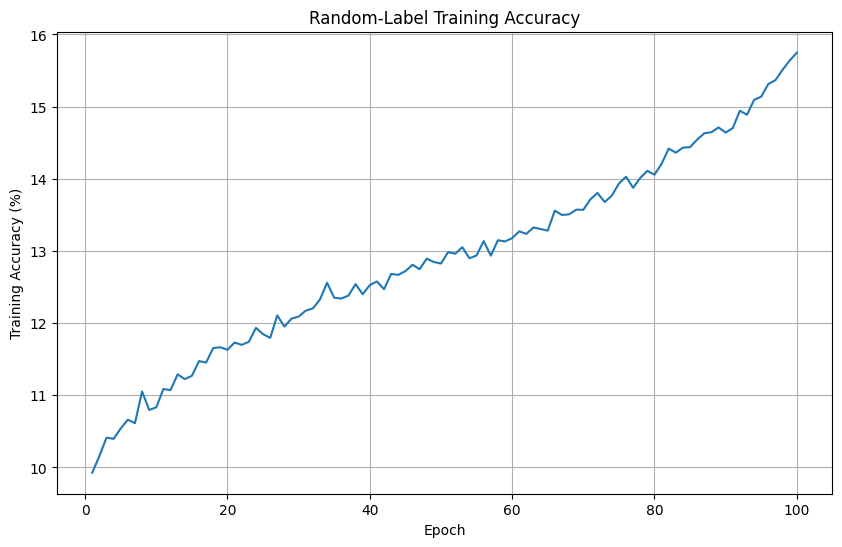

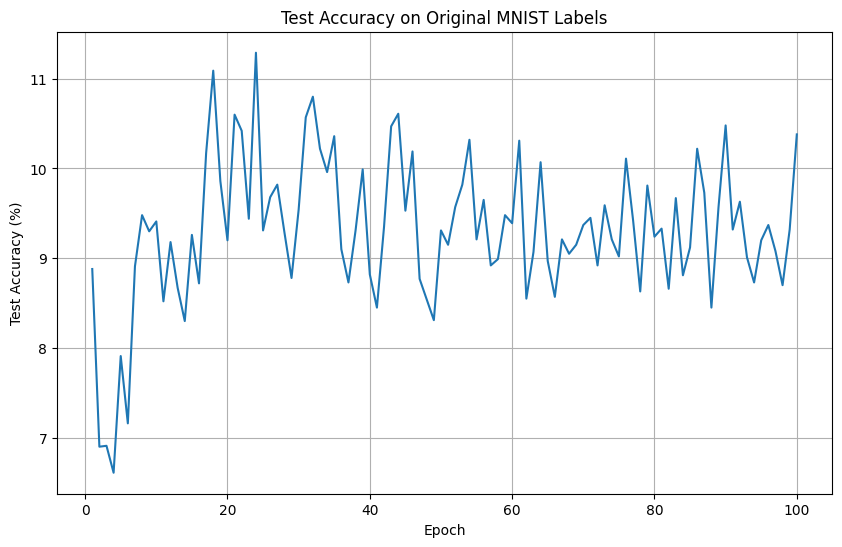

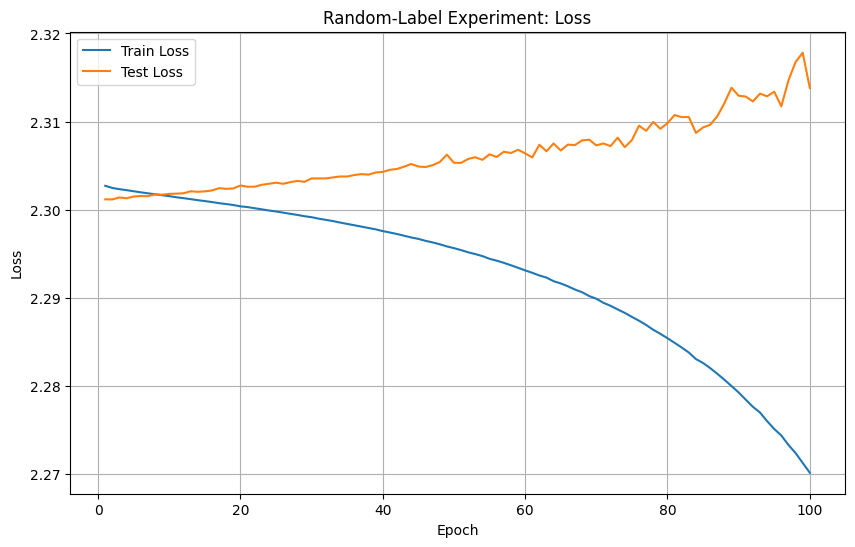


Saved: experiment_3_random_labels_100_epochs.csv


In [ ]:
# ============================================================
# EXPERIMENT 3B: RANDOM-LABEL MEMORIZATION
# 2048 WIDTH - 100 EPOCHS
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import numpy as np


# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42

WIDTH = 2048
EPOCHS = 100
BATCH_SIZE = 128
LEARNING_RATE = 0.01

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Width:", WIDTH)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)


# ============================================================
# 2. LOAD MNIST
# ============================================================

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# 3. CREATE RANDOM LABEL DATASET
# ============================================================

class RandomLabelDataset(Dataset):

    def __init__(self, dataset, seed=42):

        self.dataset = dataset

        generator = torch.Generator()
        generator.manual_seed(seed)

        self.random_labels = torch.randint(
            0,
            10,
            (len(dataset),),
            generator=generator
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        image, _ = self.dataset[index]

        return image, self.random_labels[index]


random_train_dataset = RandomLabelDataset(
    train_dataset,
    seed=SEED
)


# ============================================================
# 4. DATA LOADERS
# ============================================================

random_train_loader = DataLoader(
    random_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 5. MODEL
# ============================================================

class MLP(nn.Module):

    def __init__(self, width):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, 10)
        )

    def forward(self, x):
        return self.network(x)


# ============================================================
# 6. CREATE MODEL
# ============================================================

torch.manual_seed(SEED)

model = MLP(WIDTH).to(device)

parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nParameters:", parameters)


# ============================================================
# 7. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 8. TRAINING
# ============================================================

history = []

start_time = time.time()

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in random_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total

    train_accuracy = (
        100 * correct / total
    )


    # ========================================================
    # TEST ON ORIGINAL MNIST LABELS
    # ========================================================

    model.eval()

    test_loss_total = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss_total += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            test_correct += (
                predictions == labels
            ).sum().item()

            test_total += labels.size(0)

    test_loss = test_loss_total / test_total

    test_accuracy = (
        100 * test_correct / test_total
    )


    # ========================================================
    # GENERALIZATION GAP
    # ========================================================

    gap = train_accuracy - test_accuracy


    history.append({

        "epoch": epoch + 1,

        "train_loss": train_loss,

        "train_accuracy": train_accuracy,

        "test_loss": test_loss,

        "test_accuracy": test_accuracy,

        "generalization_gap": gap
    })


    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.2f}%"
    )


# ============================================================
# 9. RESULTS
# ============================================================

results = pd.DataFrame(history)

training_time = time.time() - start_time

print(
    f"\nTraining time: "
    f"{training_time / 60:.2f} minutes"
)


# ============================================================
# 10. FINAL RESULT
# ============================================================

print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)

print(
    results.iloc[-1].to_string()
)


# ============================================================
# 11. TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results["epoch"],
    results["train_accuracy"]
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title(
    "Random-Label Training Accuracy"
)

plt.grid(True)

plt.show()


# ============================================================
# 12. TEST ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results["epoch"],
    results["test_accuracy"]
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title(
    "Test Accuracy on Original MNIST Labels"
)

plt.grid(True)

plt.show()


# ============================================================
# 13. LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results["epoch"],
    results["train_loss"],
    label="Train Loss"
)

plt.plot(
    results["epoch"],
    results["test_loss"],
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Random-Label Experiment: Loss"
)

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 14. SAVE RESULTS
# ============================================================

results.to_csv(
    "experiment_3_random_labels_100_epochs.csv",
    index=False
)

print(
    "\nSaved: "
    "experiment_3_random_labels_100_epochs.csv"
)

### Conclusion

After 100 epochs, the model achieved only 15.75% training accuracy, while test accuracy remained close to the 10% chance level. Thus, longer SGD training did not enable memorization of the random labels in this setting.

This suggests that memorization depends not only on parameter count, but also on the optimization and training configuration.